In [5]:
!pip install pandas matplotlib seaborn mysql-connector-python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="123456789",
    database="olist"
)

orders   = pd.read_sql("SELECT * FROM olist_orders_dataset",   conn)
items    = pd.read_sql("SELECT * FROM olist_order_items_dataset", conn)
reviews  = pd.read_sql("SELECT * FROM olist_order_reviews_dataset", conn)
customers= pd.read_sql("SELECT * FROM olist_customers_dataset", conn)
payments = pd.read_sql("SELECT * FROM olist_order_payments_dataset", conn)
sellers = pd.read_sql("SELECT * FROM olist_sellers_dataset", conn)

conn.close()
print("Tables loaded.")
print("Orders shape:", orders.shape)

C:\Users\ANJALI\AppData\Local\Temp\ipykernel_19888\3635086122.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders   = pd.read_sql("SELECT * FROM olist_orders_dataset",   conn)
C:\Users\ANJALI\AppData\Local\Temp\ipykernel_19888\3635086122.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  items    = pd.read_sql("SELECT * FROM olist_order_items_dataset", conn)
C:\Users\ANJALI\AppData\Local\Temp\ipykernel_19888\3635086122.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  reviews  = pd.read_sql("SELECT * FROM olist

Tables loaded.
Orders shape: (99441, 8)


C:\Users\ANJALI\AppData\Local\Temp\ipykernel_19888\3635086122.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sellers = pd.read_sql("SELECT * FROM olist_sellers_dataset", conn)


In [6]:
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders['delay_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

print(orders[['order_id','order_status','delay_days']].head())

                           order_id order_status  delay_days
0  e481f51cbdc54678b7cc49136f2d6af7    delivered        -8.0
1  53cdb2fc8bc7dce0b6741e2150273451    delivered        -6.0
2  47770eb9100c2d0c44946d9cf07ec65d    delivered       -18.0
3  949d5b44dbf5de918fe9c16f97b45f8a    delivered       -13.0
4  ad21c59c0840e6cb83a9ceb5573f8159    delivered       -10.0


In [7]:
df = orders.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)
print("Merged shape:", df.shape)
print(df[['order_id','delay_days','review_score']].head())

Merged shape: (99441, 10)
                           order_id  delay_days  review_score
0  e481f51cbdc54678b7cc49136f2d6af7        -8.0           NaN
1  53cdb2fc8bc7dce0b6741e2150273451        -6.0           NaN
2  47770eb9100c2d0c44946d9cf07ec65d       -18.0           NaN
3  949d5b44dbf5de918fe9c16f97b45f8a       -13.0           NaN
4  ad21c59c0840e6cb83a9ceb5573f8159       -10.0           NaN


C:\Users\ANJALI\AppData\Local\Temp\ipykernel_19888\2628137204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


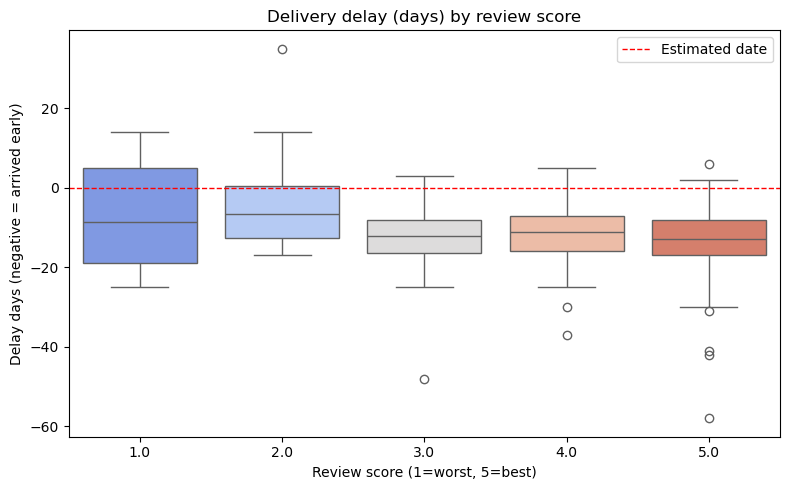

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df.dropna(subset=['review_score','delay_days']),
    x='review_score',
    y='delay_days',
    palette='coolwarm'
)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Estimated date')
plt.title('Delivery delay (days) by review score')
plt.xlabel('Review score (1=worst, 5=best)')
plt.ylabel('Delay days (negative = arrived early)')
plt.legend()
plt.tight_layout()
plt.savefig('delay_vs_review.png', dpi=150)
plt.show()

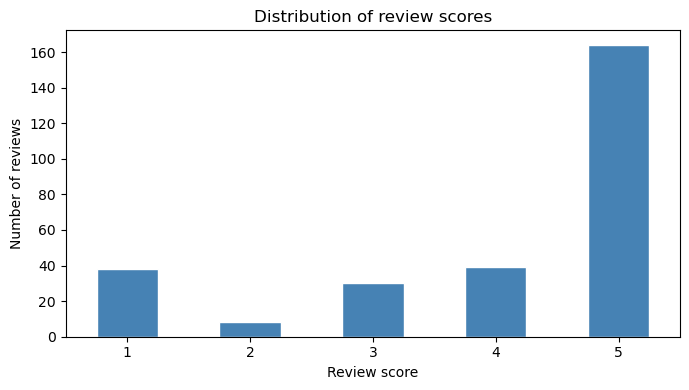

In [9]:
plt.figure(figsize=(7,4))
reviews['review_score'].value_counts().sort_index().plot(
    kind='bar',
    color='steelblue',
    edgecolor='white'
)
plt.title('Distribution of review scores')
plt.xlabel('Review score')
plt.ylabel('Number of reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('review_distribution.png', dpi=150)
plt.show()

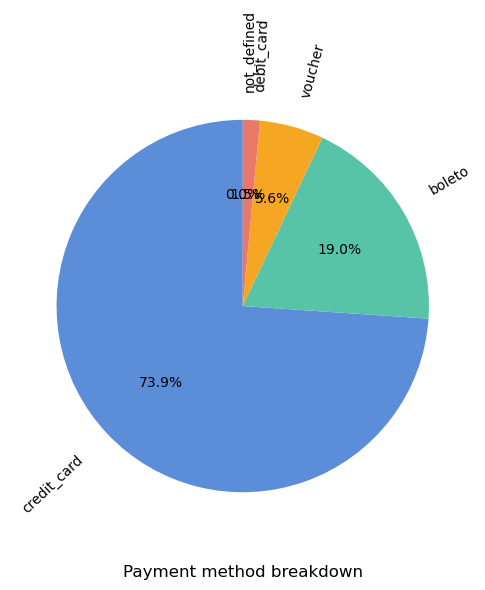

In [10]:
plt.figure(figsize=(6,6))
payments['payment_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    labeldistance = 1.15,
    rotatelabels = True,
    colors=['#5b8dd9','#57c4a7','#f5a623','#e8796a']
)
plt.title('Payment method breakdown', y = -0.1)
plt.ylabel('')
plt.tight_layout()
plt.savefig('payment_methods.png', dpi=150)

plt.show()

segment
Lost                  23328
Loyal                 23308
At risk               23230
Champions             11825
Potential loyalist    11667
Name: count, dtype: int64


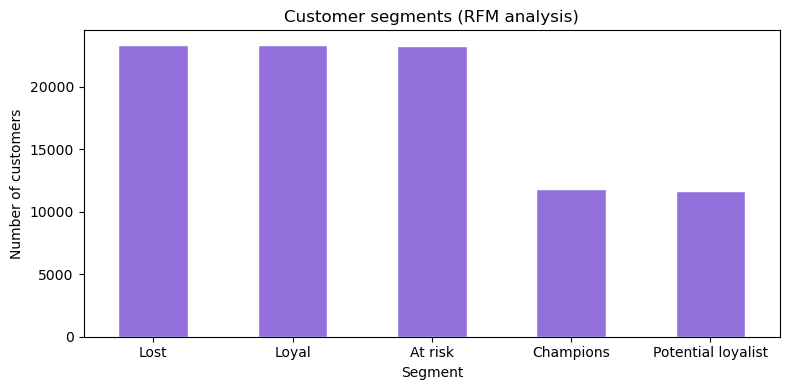

RFM done. Saved to rfm_segments.csv


In [11]:
snapshot_date = orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

order_revenue = orders.merge(
    items.groupby('order_id')['price'].sum().reset_index(),
    on='order_id'
)

order_revenue = order_revenue.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id'
)

order_revenue = order_revenue.query(
    "order_status == 'delivered'"
)

rfm = order_revenue.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp',
                  lambda x: (snapshot_date - x.max()).days),
    frequency = ('order_id', 'count'),
    monetary  = ('price',    'sum')
).reset_index()

rfm['R'] = pd.qcut(rfm['recency'],   4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['monetary'],  4, labels=[1,2,3,4])

def segment(row):
    r, f, m = int(row['R']), int(row['F']), int(row['M'])
    if r >= 4 and f >= 3: return 'Champions'
    if r >= 3 and f >= 2: return 'Loyal'
    if r >= 3 and f == 1: return 'Potential loyalist'
    if r == 2:             return 'At risk'
    return                        'Lost'

rfm['segment'] = rfm.apply(segment, axis=1)

print(rfm['segment'].value_counts())
rfm.to_csv('rfm_segments.csv', index=False)
plt.figure(figsize=(8,4))
rfm['segment'].value_counts().plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Customer segments (RFM analysis)')
plt.xlabel('Segment')
plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150)
plt.show()
print("RFM done. Saved to rfm_segments.csv")

Churn rate: 70.8%
Churned: 66107 | Active: 27251

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5450
           1       1.00      1.00      1.00     13222

    accuracy                           1.00     18672
   macro avg       1.00      1.00      1.00     18672
weighted avg       1.00      1.00      1.00     18672

AUC-ROC Score: 1.000


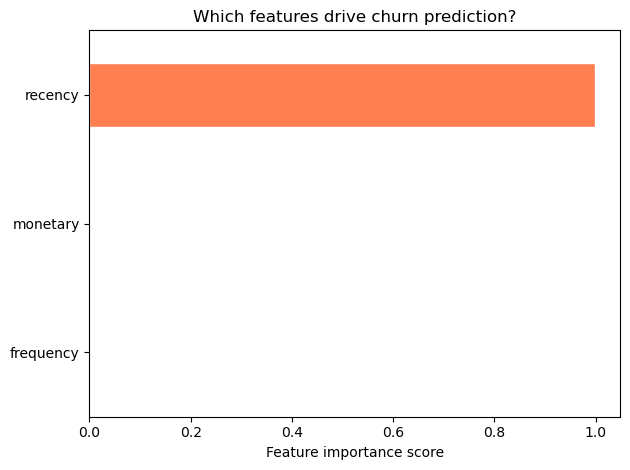

Model saved as churn_model.pkl


In [12]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pickle

rfm = pd.read_csv('rfm_segments.csv')

rfm['churned'] = (rfm['recency'] > 180).astype(int)
print(f"Churn rate: {rfm['churned'].mean()*100:.1f}%")
print(f"Churned: {rfm['churned'].sum()} | Active: {(rfm['churned']==0).sum()}")

features = ['recency', 'frequency', 'monetary']
X = rfm[features]
y = rfm['churned']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.3f}")
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='coral', edgecolor='white')
plt.title('Which features drive churn prediction?')
plt.xlabel('Feature importance score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

pickle.dump(model, open('churn_model.pkl', 'wb'))
print("Model saved as churn_model.pkl")

In [18]:
rfm['churn_prediction'] = model.predict(
    rfm[['recency', 'frequency', 'monetary']]
)

rfm['churn_probability'] = model.predict_proba(
    rfm[['recency', 'frequency', 'monetary']]
)[:, 1]

# Save final dashboard-ready file
rfm.to_csv('churn_predictions.csv', index=False)

print("churn_predictions.csv saved successfully")
print(rfm.head())

churn_predictions.csv saved successfully
                 customer_unique_id  recency  frequency  monetary  R  F  M  \
0  0000366f3b9a7992bf8c76cfdf3221e2      161          1    129.90  4  1  3   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     18.90  4  1  1   
2  0000f46a3911fa3c0805444483337064      586          1     69.00  1  1  2   
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     25.99  2  1  1   
4  0004aac84e0df4da2b147fca70cf8255      337          1    180.00  2  1  4   

              segment  churned  churn_prediction  churn_probability  
0  Potential loyalist        0                 0                0.0  
1  Potential loyalist        0                 0                0.0  
2                Lost        1                 1                1.0  
3             At risk        1                 1                1.0  
4             At risk        1                 1                1.0  
